In [1]:
import sys
sys.path.append("../../")

%load_ext autoreload
%autoreload 2

In [58]:
import dsrl.offline_safety_gymnasium  # type: ignore
import gymnasium as gym
import joblib
import math

import dsrl.infos as dsrl_infos
import numpy as np
import torch
import torch.nn as nn

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# t-SNE plot import
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


from dsrl_model.utils.models import ExpCostModel, ContrastiveCostModel, SafeTransformerCritic, EnsembleValue
from dsrl_model.utils.dsrl_dataset import get_dataset_in_d4rl_format, get_neg_and_union_data_2

In [59]:
def load_cost_model(obs_dim, act_dim, hidden_size, path, device, is_attention=False, is_contrastive=False, horizon=-1):
    if is_attention:
        cost_model = SafeTransformerCritic(
            obs_dim=obs_dim,
            act_dim=act_dim,
            horizon=horizon,
            latent_dim=hidden_size,
            device=device
        )
    elif is_contrastive:
        cost_model = ContrastiveCostModel(
            obs_dim=obs_dim + act_dim, hidden_sizes=[hidden_size, hidden_size]
        ).to(device)
    else:
        cost_model = ExpCostModel(
            obs_dim=obs_dim + act_dim, hidden_sizes=[hidden_size, hidden_size]
        ).to(device)
    cost_model.load_state_dict(torch.load(path, weights_only=True, map_location=device))
    cost_model.eval()
    return cost_model


def load_value_model(obs_dim, act_dim, hidden_size, path, device):
    value_model = EnsembleValue(
        obs_dim=obs_dim + act_dim,
        hidden_sizes=[hidden_size,],
    ).to(device)
    value_model.load_state_dict(torch.load(path, weights_only=True, map_location=device))
    value_model.eval()
    return value_model

In [60]:
def get_env(task):
    env = gym.make(task)
    obs_space, act_space = env.observation_space, env.action_space
    return env, obs_space.shape[0], act_space.shape[0]

In [61]:
def get_post_processed_dataset(env, data):
    density = 1.0
    cbins, rbins = 10, 50
    max_npb, min_npb = 30, 2
    
    inpaint_ranges = ((0.0, 1.0, 0.0, 0.5),)
    
    data = env.pre_process_data(
        data_dict=data,
        inpaint_ranges=inpaint_ranges,
        density=density,
        cbins=cbins,
        rbins=rbins,
        max_npb=max_npb,
        min_npb=min_npb,
    )
    return data


def get_dataset(env, task):
    data = env.get_dataset()
    data = get_post_processed_dataset(env, data)
    return data

In [62]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

#### Get cost embeddings 

In [63]:
def get_cost_embedding(data, cost_model, norm=False):
    observations, actions = torch.Tensor(data["observations"]), torch.Tensor(data["actions"])
    if norm:
        mu, std = torch.mean(observations, dim=0), torch.std(observations, dim=0)
        observations = (observations - mu) / (std + 1e-6)
    z, _ = cost_model(torch.cat([observations, actions], dim=1))
    z = z.detach().cpu().numpy()
    return z


def filter_cost_embedding_by_indx(data, group_data_idxs, embeddings):
    dones_idx = np.where((data["terminals"] == 1) | (data["timeouts"] == 1))[0]
    group_embds = []
    for data_idxs in group_data_idxs:
        filter_embds = []
        for i in range(dones_idx.shape[0]):
            if i not in data_idxs:
                continue
            start = 0 if i == 0 else dones_idx[i - 1] + 1
            end = dones_idx[i] + 1
            rep_embds = np.sum(embeddings[start:end], axis=0, keepdims=True)
            filter_embds.append(rep_embds)
        filter_embds = np.concatenate(filter_embds, axis=0)
        filter_embds = filter_embds / np.linalg.norm(filter_embds, axis=1, keepdims=True)
        group_embds.append(filter_embds)
    return group_embds


def get_tsne_vectors(group_embeddings, dim=3, seed=0, do_norm=False):
    tsne = TSNE(n_components=dim, perplexity=50, random_state=seed, init='random')
    
    embds_size = [embds.shape[0] for embds in group_embeddings]
    embds_ends = np.cumsum(embds_size)
    group_embeddings = np.concatenate(group_embeddings, axis=0)
    vec = tsne.fit_transform(group_embeddings)
    if do_norm:
        vec = vec / np.linalg.norm(vec, axis=1, keepdims=True)
    
    group_vec = []
    for i in range(len(embds_ends)):
        start = 0 if i==0 else embds_ends[i-1]
        end = embds_ends[i]
        group_vec.append(vec[start:end])

    return group_vec

#### Get predicted cost information

In [64]:
def get_neg_z(path):
    state_dict = joblib.load(path, mmap_mode="r")
    return state_dict["neg_z"]


def running_sum(array, num=None):
    num = num or array.shape[0]
    a, i = [], 0
    while i < array.shape[0]:
        a.append(np.sum(array[i:i+num]))
        i += num
    return a


def get_true_cost_info_data(data):
    dones_idx = np.where((data["terminals"] == 1) | (data["timeouts"] == 1))[0]
    reward_trajs, true_cost_trajs = [], []
    rewards, costs = data["rewards"], data["costs"]
    for i in range(dones_idx.shape[0]):
        start = 0 if i == 0 else dones_idx[i - 1] + 1
        end = dones_idx[i] + 1
        reward_trajs.extend(running_sum(rewards[start:end]))
        true_cost_trajs.extend(running_sum(costs[start:end]))
    return np.array(reward_trajs), np.array(true_cost_trajs)


def running_sum_horizon(arr, hz=None):
    hz = hz or arr.shape[0]
    a, i = [], 0
    while (i + hz) <= arr.shape[0]:
        a.append(np.sum(arr[i: i+hz]))
        i += 1
    return a
    

def get_true_cost_reward_dist_trajectory(data, hz=None):
    dones_idx = np.where((data["terminals"] == 1) | (data["timeouts"] == 1))[0]
    reward_traj, cost_traj = [], []
    rewards, costs = data["rewards"], data["costs"]
    for i in range(dones_idx.shape[0]):
        start = 0 if i==0 else dones_idx[i-1] + 1
        end = dones_idx[i] + 1
        reward_traj.append(running_sum_horizon(rewards[start:end], hz))
        cost_traj.append(running_sum_horizon(costs[start:end], hz))
    traj_reward_mean, traj_reward_std = np.mean(reward_traj, axis=0), np.std(reward_traj, axis=0)
    traj_cost_mean, traj_cost_std = np.mean(cost_traj, axis=0), np.std(cost_traj, axis=0)
    return (traj_reward_mean, traj_reward_std), (traj_cost_mean, traj_cost_std) 


def get_pred_cost_info_data(data, cost_model, is_contrastive=False, norm=False, neg_z=None):
    dones_idx = np.where((data["terminals"] == 1) | (data["timeouts"] == 1))[0]
    pred_cost_trajs = []
    observations, actions = torch.Tensor(data["observations"]), torch.Tensor(data["actions"])
    if norm:
        mu, std = torch.mean(observations, dim=0), torch.std(observations, dim=0)
        observations = (observations - mu) / (std + 1e-6)
    if is_contrastive:
        _, pred_costs = cost_model(torch.cat([observations, actions], dim=1))
        pred_costs = pred_costs.detach().cpu().numpy()
        # neg_z = neg_z.reshape(1, -1)
        # pred_costs = (np.matmul(z, neg_z.T).squeeze() + 1) / 2
    else:
        pred_costs = cost_model(
            torch.cat([observations, actions], dim=1), use_sigmoid=True
        ).detach().squeeze().cpu().numpy()

    # pred_costs = np.where(pred_costs > 0.5, 1.0, 0.0)
    for i in range(dones_idx.shape[0]):
        start = 0 if i == 0 else dones_idx[i - 1] + 1
        end = dones_idx[i] + 1
        pred_cost_trajs.extend(running_sum(pred_costs[start:end]))
    return np.array(pred_cost_trajs)


def get_attn_pred_cost_info_data(data, cost_model, horizon, norm=False):
    dones_idx = np.where((data["terminals"] == 1) | (data["timeouts"] == 1))[0]
    pred_cost_trajs = []
    observations, actions = torch.Tensor(data["observations"]), torch.Tensor(data["actions"])
    if norm:
        mu, std = torch.mean(observations, dim=0), torch.std(observations, dim=0)
        observations = (observations - mu) / (std + 1e-6)
    for i in range(dones_idx.shape[0]):
        start = 0 if i == 0 else dones_idx[i - 1] + 1
        end = dones_idx[i] + 1
        o, a = observations[start:end], actions[start:end]
        batch_size = o.shape[0] // horizon
        o, a = o[:batch_size*horizon], a[:batch_size*horizon]
        o, a = o.view(batch_size, horizon, -1), a.view(batch_size, horizon, -1)
        o, a = o.permute(1, 0, 2), a.permute(1, 0, 2)
        c = cost_model(torch.cat([o,a], dim=-1), use_sigmoid=True)
        pred_cost_trajs.append(torch.sum(c).item() * horizon)
    return np.array(pred_cost_trajs)

#### Get predicted value information

In [65]:
def get_pred_value_info_data(data, value_cost, norm=False):
    dones_idx = np.where((data["terminals"] == 1) | (data["timeouts"] == 1))[0]
    observations, actions = torch.Tensor(data["observations"]), torch.Tensor(data["actions"])
    if norm:
        mu, std = torch.mean(observations, dim=0), torch.std(observations, dim=0)
        observations = (observations - mu) / (std + 1e-6)    
    start_idx = np.concatenate([[0,], dones_idx[:-1]+1])
    v1, v2 = value_cost.V(
        torch.cat([observations[start_idx], actions[start_idx]], dim=1)
    )
    pred_value_trajs = torch.max(v1, v2).detach().cpu().numpy()
    return pred_value_trajs


def discounted_cum_sum(vec, discount):
    horizon = vec.shape[0]
    value = np.zeros(vec.shape)
    value[-1] = vec[-1]
    for i in reversed(range(horizon-1)):
        value[i] = vec[i] + discount * value[i+1]
    return value


def get_cost_value(data, data_idxs, value_cost, gamma, norm=False):
    dones_idx = np.where((data["terminals"] == 1) | (data["timeouts"] == 1))[0]
    observations, actions = torch.Tensor(data["observations"]), torch.Tensor(data["actions"])
    costs = data["costs"]
    if norm:
        mu, std = torch.mean(observations, dim=0), torch.std(observations, dim=0)
        observations = (observations - mu) / (std + 1e-6)
    true_vs, pred_vs= [], []
    for i in range(dones_idx.shape[0]):
        if i not in data_idxs:
            continue
        start = 0 if i == 0 else dones_idx[i - 1] + 1
        end = dones_idx[i] + 1
        o, a, c = observations[start:end], actions[start:end], costs[start:end]
        true_vs.append(discounted_cum_sum(c, gamma))
        pred_vs.append(
            torch.max(*value_cost.V(torch.cat([o, a], dim=1))).detach().cpu().numpy()
        )
    return true_vs, pred_vs    

#### Trajectory binning

In [66]:
def traj_binning(traj_cost, bin_size=25):
    min_cost, max_cost = traj_cost.min(), traj_cost.max()
    c = min_cost
    bins = []
    while c < max_cost:
        bins.append([])
        c = min(bin_size + c, max_cost)
    
    for idx, cost in enumerate(traj_cost):
        cost -= min_cost
        i = min(int(cost // bin_size), len(bins)-1)    
        bins[i].append(idx)
    
    return bins

#### Plot

In [122]:
def light_color(color, amount=0.5):
    try:
        c = mcolors.cnames[color]  # convert named color to hex
    except KeyError:
        c = color  # if it's not a named color, it might already be hex or RGB

    rgb = mcolors.to_rgb(c)  # convert to RGB format
    light_color = [(1 - amount) * channel + amount for channel in rgb]  # blend with white
    return light_color


def plot_line(xmean, xstd=None, label=None):
    fig, ax = plt.subplots(figsize=(6, 4))
    timestep = np.arange(xmean.shape[0])
    ax.plot(timestep, xmean, color='blue', lw=4.3, label=label, 
            linestyle='--', marker='d', markevery=7, markersize=10)

    if xstd is not None:
        xl, xu = xmean - xstd, xmean + xstd
        ax.fill_between(timestep, xl, xu, color=light_color('blue'), alpha=0.4)


def plot_pred_cost_trajectories(pred_traj_cost, bins, task_name):
    fig, ax = plt.subplots(figsize=(6, 4))
    # color = "red"
    for i, bin in enumerate(bins):
        costs = pred_traj_cost[bin]
        # amount = (0.9 - 0.9/len(bins) * i)
        ax.plot(costs, [i]*len(bin), "o")
    
    ax.set_title(task_name)
    ax.set_xlabel("Predicted Cost")
    ax.set_ylabel("Binned True Cost")
    
    
def plot_pred_cost_trajectories_marginal(true_traj_cost, pred_traj_cost, task_name):
    fig, ax = plt.subplots(figsize=(6, 4))
    
    ep = 1e-4
    mat_size = 25
    matrix = np.zeros((mat_size, mat_size), dtype=np.float32)
    
    true_min, true_max = true_traj_cost.min(), true_traj_cost.max()
    s_true_traj_cost = mat_size * (true_traj_cost - true_min) / (true_max - true_min)
    
    # pred_min = pred_traj_cost.min()
    pred_min = pred_traj_cost.mean() - 2.0 * pred_traj_cost.std()
    # pred_max = pred_traj_cost.max()
    pred_max = pred_traj_cost.mean() + 2.0 * pred_traj_cost.std()
    print(pred_min, pred_max)
    pred_min = pred_min if pred_min > 0 else pred_traj_cost.min()
    pred_max = pred_max if pred_max < pred_traj_cost.max() else pred_traj_cost.max()
    s_pred_traj_cost = mat_size * (pred_traj_cost - pred_min) / (pred_max - pred_min)
    
    for tc, pc in zip(s_true_traj_cost, s_pred_traj_cost):
        tc = min(max(tc, 0.0), mat_size-ep)
        pc = min(max(pc, 0.0), mat_size-ep)
        tc, pc = int(tc // 1), int(pc // 1)
        matrix[tc, pc] += 1
    
    # matrix = matrix.clip(max=(matrix.mean() + matrix.std()))
    matrix = matrix / matrix.sum(axis=1, keepdims=True)

    cax = ax.imshow(matrix, cmap="viridis", interpolation="nearest", vmin=0, vmax=0.4)
    # fig.subplots_adjust(bottom=0.2)

    cbar = fig.colorbar(cax, ax=ax)
    cbar.set_ticks([0, 0.1, 0.2, 0.3, 0.4])
    ax.set_xticks([0, 5, 10, 15, 20])
    ax.set_yticks([0, 5, 10, 15, 20])
    ax.set_title(task_name.replace("_", " "), fontsize='x-large')
    ax.set_xlabel("predicted trajectory cost", fontsize='x-large')
    ax.set_ylabel("true trajectory cost", fontsize='x-large')
    return fig


def check_to_array_same(arr1, arr2):
    if arr1.shape != arr2.shape:
        return False

    ep = 1e-3
    arr1, arr2 = arr1.flatten(), arr2.flatten()
    for a, b in zip(arr1, arr2):
        if abs(a-b) > ep:
            return False
    return True


def plot_trajectory_dist(true_traj_cost, pred_traj_cost, task_name):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    
    ep = 1e-4
    mat_size = 5
    matrix = np.zeros((mat_size, mat_size), dtype=np.float32)
    
    true_min, true_max = true_traj_cost.min(), true_traj_cost.max()
    s_true_traj_cost = mat_size * (true_traj_cost - true_min) / (true_max - true_min)
    
    # pred_min = pred_traj_cost.min()
    pred_min = pred_traj_cost.mean() - 2.0 * pred_traj_cost.std()
    # pred_max = pred_traj_cost.max()
    pred_max = pred_traj_cost.mean() + 2.0 * pred_traj_cost.std()
    print(pred_min, pred_max)
    pred_min = pred_min if pred_min > pred_traj_cost.min() else pred_traj_cost.min()
    pred_max = pred_max if pred_max < pred_traj_cost.max() else pred_traj_cost.max()
    s_pred_traj_cost = mat_size * (pred_traj_cost - pred_min) / (pred_max - pred_min)
    
    for tc, pc in zip(s_true_traj_cost, s_pred_traj_cost):
        tc = min(max(tc, 0.0), mat_size-ep)
        pc = min(max(pc, 0.0), mat_size-ep)
        tc, pc = int(tc // 1), int(pc // 1)
        matrix[pc, tc] += 1
    
    total_trajs = matrix.sum()
    
    true_prob = matrix.sum(axis=0) / total_trajs
    pred_prob = matrix.sum(axis=1) / total_trajs
    
    ymax = max(pred_prob.max(), true_prob.max()) + 0.01

    ax[0].bar(np.arange(mat_size), true_prob)
    ax[0].set_ylim(0, ymax)
    ax[0].set_xlabel("trajectory cost", fontsize='x-large')
    ax[0].set_ylabel("percentage of trajectories", fontsize='x-large')
    ax[0].set_title("True Cost Dist", fontsize='x-large')
    
    ax[1].bar(np.arange(mat_size), pred_prob)
    ax[1].set_ylim(0, ymax)
    ax[1].set_xlabel("trajectory cost", fontsize='x-large')
    ax[1].set_title("Predicted Cost Dist", fontsize='x-large')
    
    fig.suptitle(task_name.replace("_", " "), fontsize='x-large')
    
    return fig


def plot_pred_cost_trajectories_joint_prob(true_traj_cost, pred_traj_cost, task_name):
    fig, ax = plt.subplots(figsize=(6, 4))
    
    ep = 1e-4
    mat_size = 25
    matrix = np.zeros((mat_size, mat_size), dtype=np.float32)
    
    true_min, true_max = true_traj_cost.min(), true_traj_cost.max()
    s_true_traj_cost = mat_size * (true_traj_cost - true_min) / (true_max - true_min)
    
    pred_min = pred_traj_cost.mean() - 2.0 * pred_traj_cost.std()
    pred_max = pred_traj_cost.mean() + 2.0 * pred_traj_cost.std()
    print(f"pred_min: {pred_min}, true_pred_min: {pred_traj_cost.min()}")
    print(f"pred_max: {pred_max}, true_pred_max: {pred_traj_cost.max()}")
    
    pred_min = pred_min if pred_min > pred_traj_cost.min() else pred_traj_cost.min()
    pred_max = pred_max if pred_max < pred_traj_cost.max() else pred_traj_cost.max()
    print(pred_min, pred_max)
    
    s_pred_traj_cost = mat_size * (pred_traj_cost - pred_min) / (pred_max - pred_min)
    
    for tc, pc in zip(s_true_traj_cost, s_pred_traj_cost):
        tc = min(max(tc, 0.0), mat_size-ep)
        pc = min(max(pc, 0.0), mat_size-ep)
        tc, pc = int(tc // 1), int(pc // 1)
        matrix[pc, tc] += 1
    
    # matrix = matrix.clip(max=(matrix.mean() + matrix.std()))
    
    pred_total = matrix.sum(axis=1, keepdims=True)
    pred_prob = pred_total / pred_total.sum()

    true_total = matrix.sum(axis=0, keepdims=True) 
    true_prob = true_total / true_total.sum()

    marginal_prob = matrix / true_total
    joint_prob = marginal_prob * true_prob
    
    print("true_prob", check_to_array_same(joint_prob.sum(axis=0, keepdims=True), true_prob))
    print("pred_prob", check_to_array_same(joint_prob.sum(axis=1, keepdims=True), pred_prob))
    
    vmin, vmax = 0.0, 0.02
    cax = ax.imshow(joint_prob, cmap="viridis", interpolation="nearest", vmin=vmin, vmax=vmax, origin="lower")
    # fig.subplots_adjust(bottom=0.2)

    cbar = fig.colorbar(cax, ax=ax)
    cbar.set_ticks(np.linspace(vmin, vmax, num=5))
    
    # --- Fit line to the "mean brightest" points (example: mean of each row) ---
    x = np.arange(mat_size)
    rows = np.arange(mat_size)[:, None]  # row indices
    # Weighted mean row index for each column
    y_mean = (joint_prob * rows).sum(axis=0) / joint_prob.sum(axis=0)
    # Fit a line (least squares)
    m, b = np.polyfit(x, y_mean, 1)
    # Draw fitted line
    ax.plot(x, (m*x + b).clip(min=0, max=mat_size-1), color='red', linestyle='-.', linewidth=2)
    
    ax.set_xticks([0, 5, 10, 15, 20])
    ax.set_yticks([0, 5, 10, 15, 20])
    ax.set_title(task_name.replace("_", " "), fontsize='x-large')
    ax.set_xlabel("true trajectory cost", fontsize='x-large')
    ax.set_ylabel("predicted trajectory cost", fontsize='x-large')
    return fig
    

def plot_value(true_vs, pred_vs, task_name):
    fig, ax = plt.subplots(figsize=(6, 4))
    true_vs, pred_vs = np.array(true_vs), np.array(pred_vs)
    
    true_mean, true_std = np.mean(true_vs, axis=0), np.std(true_vs, axis=0)
    pred_mean, pred_std = np.mean(pred_vs, axis=0), np.std(pred_vs, axis=0)
    
    x = np.arange(len(true_mean))
    
    ax.plot(x, true_mean, label="true mean", color="red")
    ax.fill_between(x, true_mean - true_std, true_mean + true_std, color="red", alpha=0.3)
    
    ax.plot(x, pred_mean, label="pred mean", color="blue")
    ax.fill_between(x, pred_mean - pred_std, pred_mean + pred_std, color="blue", alpha=0.3)
    
    fig.legend()
    ax.set_xlabel("timesteps")
    ax.set_ylabel("cost_value")
    ax.set_title(task_name)

In [68]:
# tSNE plot

def get_spherical_plot(embedding_groups, colors, title):
    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(111, projection='3d')
    
    u = np.linspace(0, 2 * np.pi, 100)
    v = np.linspace(0, np.pi, 100)
    x = np.outer(np.cos(u), np.sin(v))
    y = np.outer(np.sin(u), np.sin(v))
    z = np.outer(np.ones(np.size(u)), np.cos(v))
    ax.plot_surface(x, y, z, color='lightgrey', alpha=0.1, linewidth=0)
    
    for i, embds in enumerate(embedding_groups):
        ax.scatter(embds[:, 0], embds[:, 1], embds[:, 2], c=colors[i], s=10)
    
    ax.set_title(title)
    ax.set_axis_off()
    ax.set_box_aspect([1, 1, 1])  # Equal aspect
    fig.subplots_adjust(left=0, right=1, top=1, bottom=0)
    
    # ax.view_init(elev=250, azim=100)  # Try changing these values!
    
    plt.show()


def get_planer_plot(embedding_groups, colors, title):
    fig, ax = plt.subplots(figsize=(6, 6))
    for i, embds in enumerate(embedding_groups):
        ax.scatter(embds[:, 0], embds[:, 1], c=colors[i], s=10, alpha=0.7)
    ax.set_title(title)
    ax.set_axis_off()
    fig.tight_layout()


#### Experiments

In [87]:
task_name = "Point_Button1"
ver = 0
tn = task_name.replace("_", "")
task = f"Offline{tn}Gymnasium-v{ver}"
# task = "OfflinePointButton1Gymnasium-v0"
device = torch.device("cpu")

gamma = 0.99

is_norm = True
norm_type = "norm" if is_norm else "no_norm"

is_attention = False
horizon = 10

is_contrastive = False
neg_z_path = f"/home/returaj/workspace/github/offline_mpc/dsrl_model/runs/safecl/{task}/{norm_type}/state.pkl"

cost_model_path = f"/home/returaj/workspace/github/offline_mpc/dsrl_model/runs/safecl/{task}/{norm_type}/cost_model_1000000.pt"
value_cost_model_path = f"/home/returaj/workspace/github/offline_mpc/dsrl_model/runs/safecl/{task}/{norm_type}/value_cost_model_1000000.pt"

Loading dataset from /home/returaj/.dsrl/datasets/SafetyPointButton1Gymnasium-v0-200-2268.hdf5


load datafile:   0%|          | 0/7 [00:00<?, ?it/s]

load datafile: 100%|██████████| 7/7 [00:11<00:00,  1.65s/it]


rmax = 41.193016052246094, rmin = 0.008822143077850342
cmax = 200.0, cmin = 0.0
before filter: traj num = 2268, transitions num = 2268000
after filter: traj num = 2268


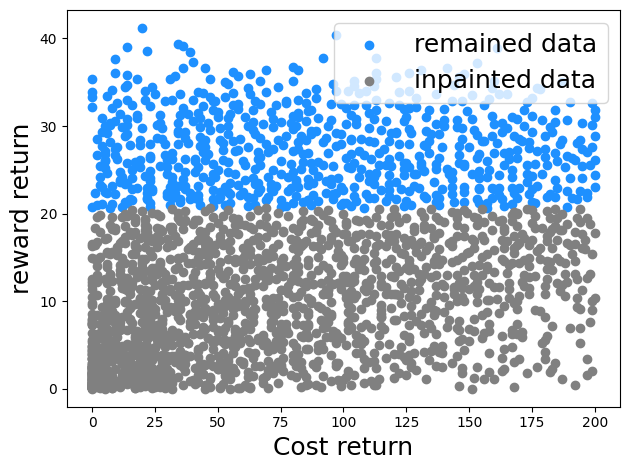

In [88]:
env, obs_dim, act_dim = get_env(task)
data = get_dataset(env, task)

In [43]:
cost_model = load_cost_model(obs_dim, act_dim, 256, cost_model_path, device,
                             is_attention=is_attention,
                             is_contrastive=is_contrastive,
                             horizon=horizon)

In [44]:
traj_reward, true_traj_cost = get_true_cost_info_data(data)
cost_bins = traj_binning(true_traj_cost, bin_size=10)

##### pred cost based experiments

In [17]:
neg_z = None
# if is_contrastive:
#     neg_z = get_neg_z(neg_z_path)

if is_attention:
    pred_traj_cost = get_attn_pred_cost_info_data(data, cost_model, horizon=10, norm=is_norm)
else:
    pred_traj_cost = get_pred_cost_info_data(data, cost_model,
                                             norm=is_norm,
                                             is_contrastive=is_contrastive,
                                             neg_z=neg_z)

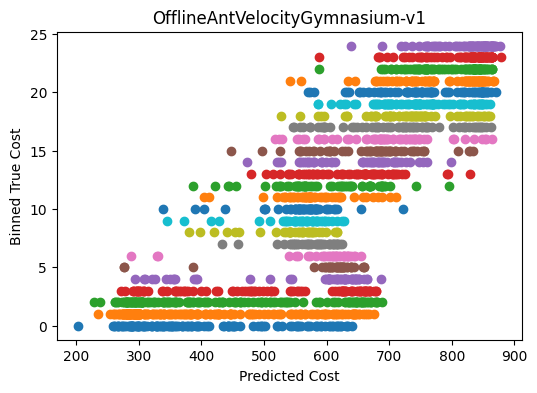

In [18]:
plot_pred_cost_trajectories(pred_traj_cost, cost_bins, task_name=task)

265.5403747558594 960.6948547363281


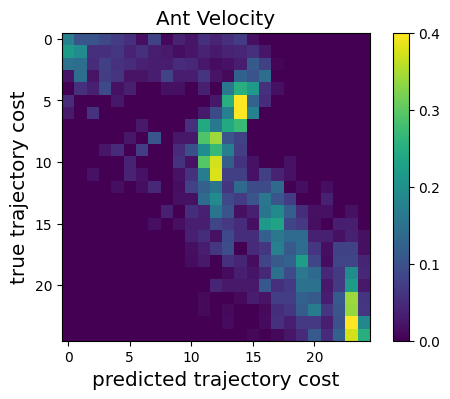

In [19]:
fig_marginal = plot_pred_cost_trajectories_marginal(true_traj_cost, pred_traj_cost, task_name=task_name)

pred_min: 265.5403747558594, true_pred_min: 202.63832092285156
pred_max: 960.6948547363281, true_pred_max: 878.4351806640625
265.5403747558594 878.4352
true_prob True
pred_prob True


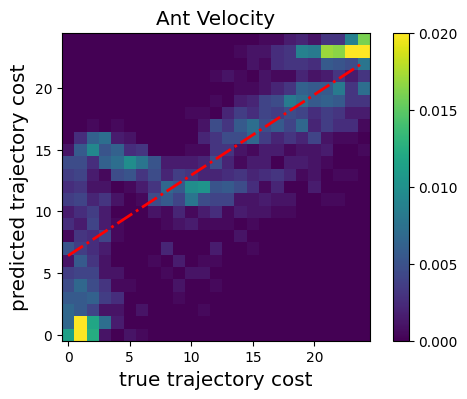

In [20]:
fig_joint = plot_pred_cost_trajectories_joint_prob(true_traj_cost, pred_traj_cost, task_name=task_name)

In [21]:
path = "/home/returaj/Documents/research/offline_safe_rl/neg_union/svg_images/safecl/neg_50/compare_cost/"
save_fig_path = f"{path}/{task_name}_joint.svg"
fig_joint.savefig(save_fig_path, format="svg", bbox_inches='tight')


path = "/home/returaj/Documents/research/offline_safe_rl/neg_union/png_images/safecl/neg_50/compare_cost/"
save_fig_path = f"{path}/{task_name}_joint.png"
fig_joint.savefig(save_fig_path, format="png", bbox_inches='tight')

265.5403747558594 960.6948547363281


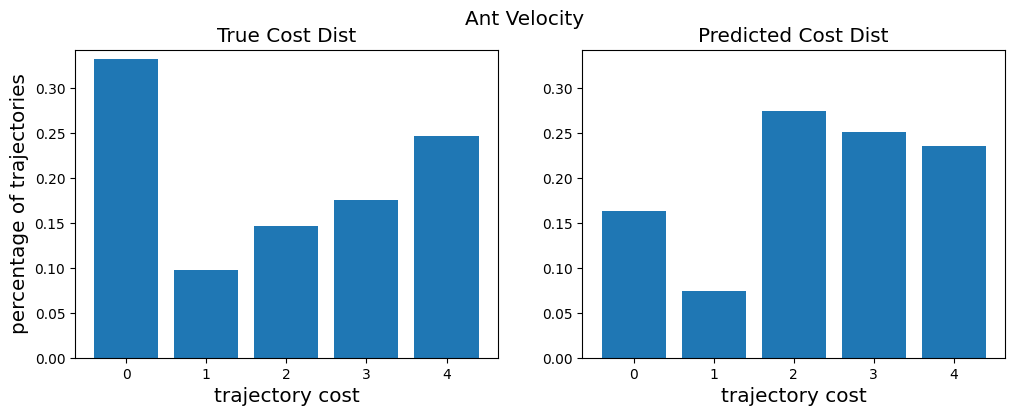

In [22]:
fig_dist = plot_trajectory_dist(true_traj_cost, pred_traj_cost, task_name)

In [23]:
path = "/home/returaj/Documents/research/offline_safe_rl/neg_union/svg_images/safecl/neg_50/compare_cost/"
save_fig_path = f"{path}/{task_name}_dist.svg"
fig_dist.savefig(save_fig_path, format="svg", bbox_inches='tight')


path = "/home/returaj/Documents/research/offline_safe_rl/neg_union/png_images/safecl/neg_50/compare_cost/"
save_fig_path = f"{path}/{task_name}_dist.png"
fig_dist.savefig(save_fig_path, format="png", bbox_inches='tight')

In [24]:
del pred_traj_cost, traj_reward, true_traj_cost, data

##### main code data experiments

Loading dataset from /home/returaj/.dsrl/datasets/SafetyPointButton1Gymnasium-v0-200-2268.hdf5


load datafile: 100%|██████████| 7/7 [00:11<00:00,  1.68s/it]


rmax = 41.193016052246094, rmin = 0.008822143077850342
cmax = 200.0, cmin = 0.0
before filter: traj num = 2268, transitions num = 2268000
after filter: traj num = 2268
Number of negative trajectory dataset: 50
Avg negative trajectory cost/reward: 164.020/27.216
Number of union trajectory dataset: 625
Avg union trajectory cost/reward: 85.418/27.456


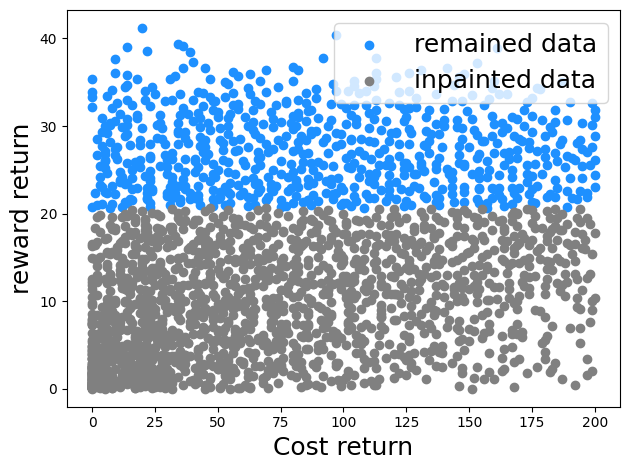

In [89]:
trajectory_cfg = {
    "density": 1.0,
    "target_cost": 25.0,
    # ((low_cost, low_reward), (high_cost, low_reward), (medium_cost, high_reward))
    "inpaint_ranges": ((0.0, 1.0, 0.0, 0.5),),
    "num_negative_trajectories": 50,
    "num_union_trajectories": -1,
    "non_pref_noise": 0.0,
}

main_data = get_dataset_in_d4rl_format(env, trajectory_cfg, task, 1000)
neg_data, union_data = get_neg_and_union_data_2(main_data, trajectory_cfg)

In [92]:
def get_dist(arr, hz=None):
    ret_arr = []
    for a in arr:
        ret_arr.append(running_sum_horizon(a, hz))
    return np.mean(ret_arr, axis=0), np.std(ret_arr, axis=0)

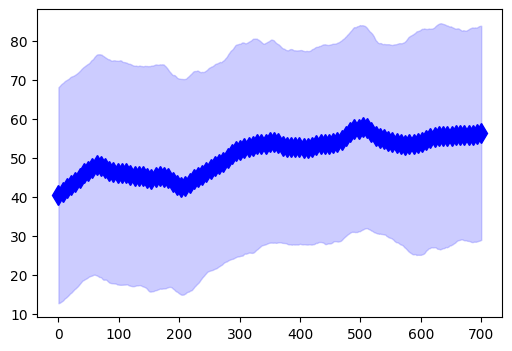

In [134]:
plot_line(*get_dist(neg_data["costs"], hz=300))

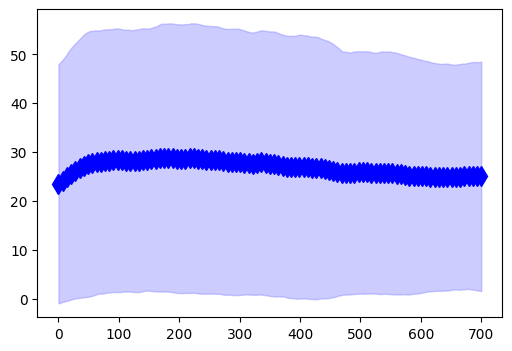

In [135]:
plot_line(*get_dist(union_data["costs"], hz=300))

In [81]:
del data, main_data

##### tSNE plots of embedding

In [42]:
cost_embeddings = get_cost_embedding(data, cost_model, norm=is_norm)

In [43]:
num_bins = len(cost_bins)
bin_indx = [i for i in range(math.floor(num_bins * 0.7), num_bins)]
bin_indx.append(0)
print(bin_indx)
colors = ["red"] * (len(bin_indx) -1) + ["blue"]
group_indx = [cost_bins[i] for i in bin_indx]

group_embds = filter_cost_embedding_by_indx(data, group_indx, cost_embeddings)

[8, 9, 10, 11, 0]


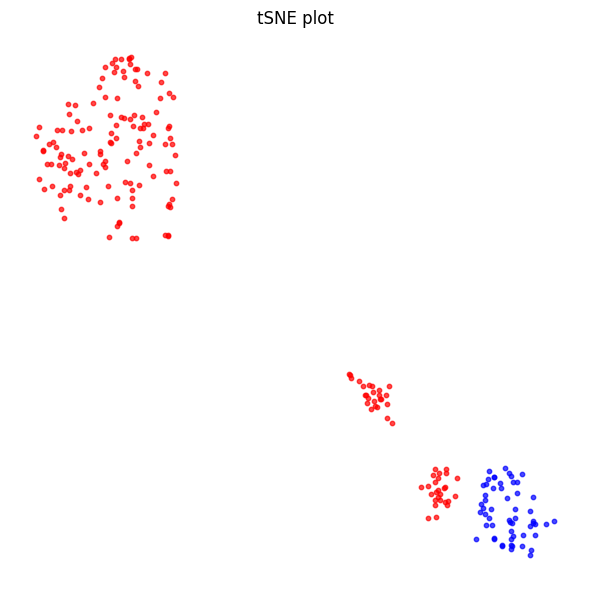

In [44]:
group_tsne_vec = get_tsne_vectors(group_embds, dim=2, do_norm=False)
get_planer_plot(group_tsne_vec, colors, title="tSNE plot")

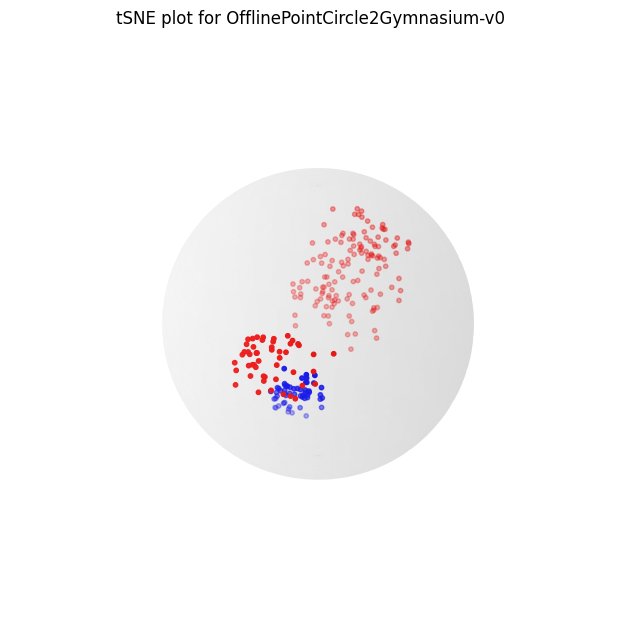

In [45]:
group_tsne_vec = get_tsne_vectors(group_embds, dim=3, do_norm=True)
get_spherical_plot(group_tsne_vec, colors, title="tSNE plot for " + task)

##### delete key to free memory

In [46]:
del group_tsne_vec, group_embds, cost_embeddings, pred_traj_cost, traj_reward, true_traj_cost, data

##### value based experiments

In [30]:
value_model = load_value_model(obs_dim, act_dim, 256, value_cost_model_path, device)

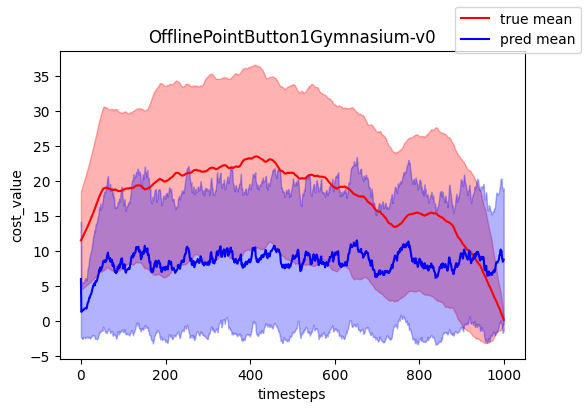

In [31]:
bin_idx = -1
true_vs, pred_vs = get_cost_value(data, cost_bins[bin_idx], value_model, gamma=gamma, norm=is_norm)
plot_value(true_vs, pred_vs, task_name=task)

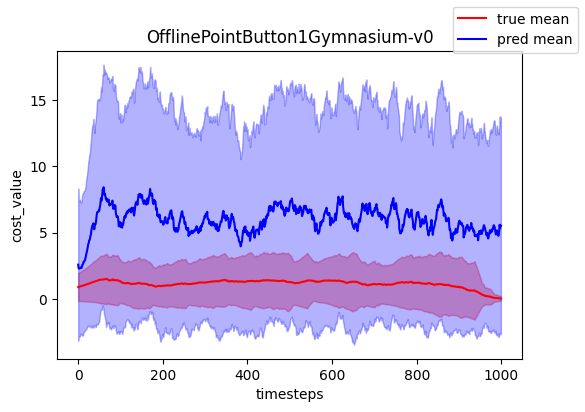

In [32]:
bin_idx = 0
true_vs, pred_vs = get_cost_value(data, cost_bins[bin_idx], value_model, gamma=gamma, norm=is_norm)
plot_value(true_vs, pred_vs, task_name=task)